In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, roc_auc_score)

In [3]:
df = pd.read_csv('Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
df = df.drop('Id', axis=1)

In [5]:
y = df['Species']
X = df.drop('Species', axis=1)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
models = {
    'Logistic Regression': LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=200, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

In [9]:
results = []

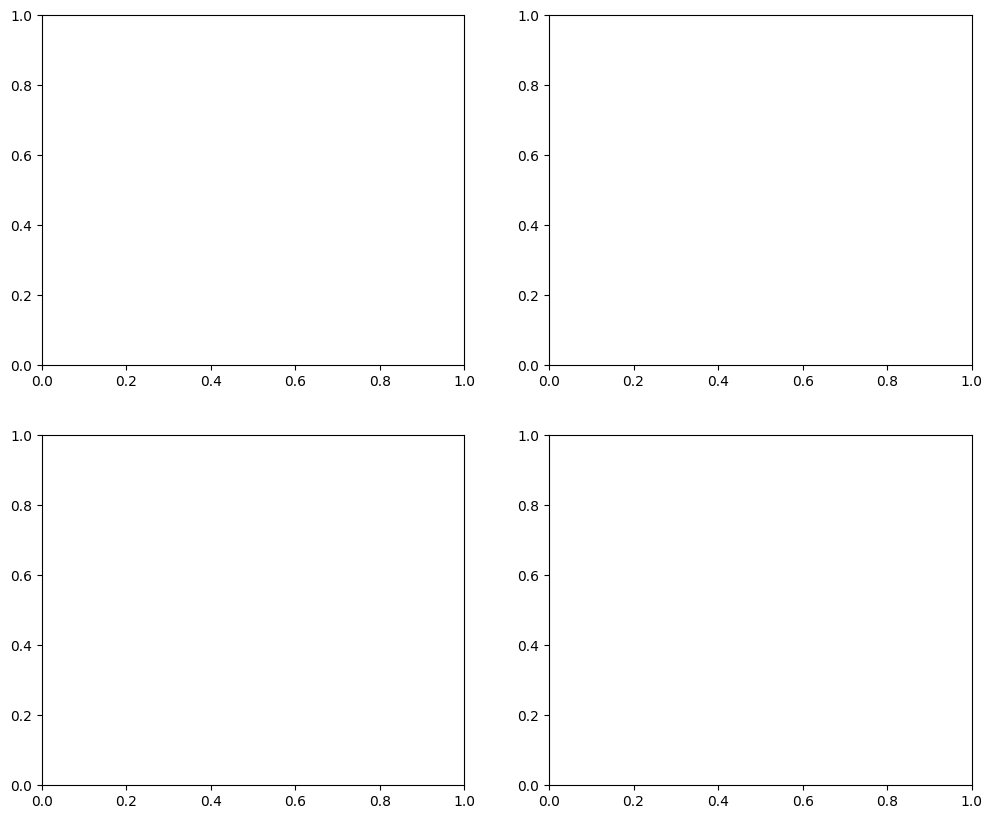

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

In [11]:
y_test_bin = label_binarize(y_test, classes=np.unique(y))

In [12]:
for idx, (name, model) in enumerate(models.items()):
    
    # --- CHALLENGE: Cross-Validation Implementation ---
    # Use scaled data for LR and KNN, unscaled for Trees
    X_cv = X_train_scaled if name in ['Logistic Regression', 'KNN'] else X_train
    cv_scores = cross_val_score(model, X_cv, y_train, cv=5, scoring='accuracy')
    
    # Train the model on the full training set
    model.fit(X_cv, y_train)
    
    # Predict on the test set
    X_test_eval = X_test_scaled if name in ['Logistic Regression', 'KNN'] else X_test
    y_pred = model.predict(X_test_eval)
    y_prob = model.predict_proba(X_test_eval)
        
    # --- Metrics Calculation ---
    # Using 'weighted' average to account for multi-class labels
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    # ROC AUC using One-vs-Rest (OvR) approach
    auc_score = roc_auc_score(y_test_bin, y_prob, multi_class='ovr', average='weighted')
    
    results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'ROC AUC': round(auc_score, 4),
        'CV Mean Accuracy': round(cv_scores.mean(), 4),
        'CV Std Dev': round(cv_scores.std(), 4)
    })
    
    # --- Visualization: Confusion Matrix ---
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], 
                xticklabels=np.unique(y), yticklabels=np.unique(y))
    axes[idx].set_title(f'Confusion Matrix - {name}')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

/opt/miniconda3/envs/main/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/miniconda3/envs/main/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/miniconda3/envs/main/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/miniconda3/envs/main/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: Futur

In [13]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [14]:
results_df = pd.DataFrame(results)
display(results_df)

,Model,Accuracy,Precision,Recall,F1-Score,ROC AUC,CV Mean Accuracy,CV Std Dev
0,Logistic Regression,0.9111,0.9155,0.9111,0.9107,0.9956,0.9810,0.0233
1,Decision Tree,0.9333,0.9444,0.9333,0.9327,0.9500,0.9429,0.0190
2,Random Forest,0.8889,0.8981,0.8889,0.8878,0.9889,0.9524,0.0301
3,KNN,0.9111,0.9298,0.9111,0.9095,0.9881,0.9524,0.0426
